# Rich ablation posttraining

Local comparison of runs from the `rich_ablation_posttrain` experiment. The tables use the last logged value; the plots use the complete MLflow metric history.

Run the notebook from the repository root. Total loss and FP loss are excluded from the main comparison because they are directly tied to the shared objectives or to the ablation configurations.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
candidates = [Path('results/ablation/rich_ablation_posttrain'), Path('rich_ablation_posttrain'), Path('../rich_ablation_posttrain')]
results_dir = next(path for path in candidates if (path / 'runs.csv').exists())
runs = pd.read_csv(results_dir / 'runs.csv')
history = pd.read_csv(results_dir / 'metric_history.csv')
last = pd.read_csv(results_dir / 'last_metrics.csv')
print(f'{len(runs)} runs, {len(history)} metric points')
runs[['run_name', 'status', 'script_scope', 'start_time_utc', 'duration_minutes']]

5 runs, 32153 metric points


,run_name,status,script_scope,start_time_utc,duration_minutes
0,rich-ablation-posttrain-full,FAILED,script_run,2026-09-03T05:10:31.664000+00:00,281.44
1,rich-ablation-posttrain-target-only,FINISHED,script_run,2026-09-03T10:42:08.549000+00:00,271.78
2,rich-ablation-posttrain-input-only,FINISHED,script_run,2026-09-03T15:14:04.423000+00:00,323.33
3,rich-ablation-posttrain-disabled,FINISHED,script_run,2026-09-03T20:37:32.491000+00:00,323.20
4,rich-ablation-posttrain-unimol,FINISHED,extra_run_in_experiment,2026-09-06T07:34:00.277000+00:00,326.18


## Final table

`use_rich_input` indicates whether rich annotations are provided to the encoder; `use_annotation_loss` indicates whether they are reconstructed. Additional runs found in the same experiment are explicitly marked.

In [3]:
columns = [
    'run_name', 'status', 'script_scope', 'param_use_rich_input',
    'param_use_annotation_loss', 'param_molecular_target',
    'train_shift_loss', 'val_shift_loss',
    'val_h_shift_mae_ppm', 'val_c_shift_mae_ppm',
    'probe_maccs_macro_auroc', 'val_fp_mae', 'val_fp_macro_mae',
    'train_annotation_rich_loss', 'val_annotation_rich_loss',
    'duration_minutes', 'gpu_peak_allocated_mb', 'gpu_peak_reserved_mb',
]
columns = [column for column in columns if column in last.columns]
final_table = last[columns].copy()
metric_columns = [column for column in columns if column not in {'run_name', 'status', 'script_scope', 'param_use_rich_input', 'param_use_annotation_loss', 'param_molecular_target'}]
final_table[metric_columns] = final_table[metric_columns].apply(pd.to_numeric, errors='coerce').round(4)
final_table

,run_name,status,script_scope,param_use_rich_input,param_use_annotation_loss,param_molecular_target,train_shift_loss,val_shift_loss,val_h_shift_mae_ppm,val_c_shift_mae_ppm,probe_maccs_macro_auroc,val_fp_mae,val_fp_macro_mae,train_annotation_rich_loss,val_annotation_rich_loss,duration_minutes,gpu_peak_allocated_mb,gpu_peak_reserved_mb
0,rich-ablation-posttrain-full,FAILED,script_run,True,True,NaN,4.4698,4.4762,0.5254,15.0345,0.7957,0.0399,0.1479,0.2454,0.2451,281.44,67679.9922,89390.0
1,rich-ablation-posttrain-target-only,FINISHED,script_run,False,True,NaN,4.9335,4.9594,1.0798,18.8752,0.7968,0.0422,0.1525,0.7425,0.7295,271.78,67678.7578,89390.0
2,rich-ablation-posttrain-input-only,FINISHED,script_run,True,False,NaN,4.3856,4.4850,0.5415,15.0984,0.7941,0.0382,0.1480,NaN,NaN,323.33,67684.5391,81202.0
3,rich-ablation-posttrain-disabled,FINISHED,script_run,False,False,NaN,4.8979,4.9512,1.0826,18.6603,0.7903,0.0412,0.1540,NaN,NaN,323.20,67684.5391,81202.0
4,rich-ablation-posttrain-unimol,FINISHED,extra_run_in_experiment,True,False,unimol,4.4672,4.4927,0.5400,15.1968,0.7826,NaN,NaN,NaN,NaN,326.18,67663.1484,73402.0


## Learning curves

The curves show shift loss, H/C MAE, the probe, FP MAE independent of the objective, and rich annotation loss. Learning rate helps interpret the short runs.

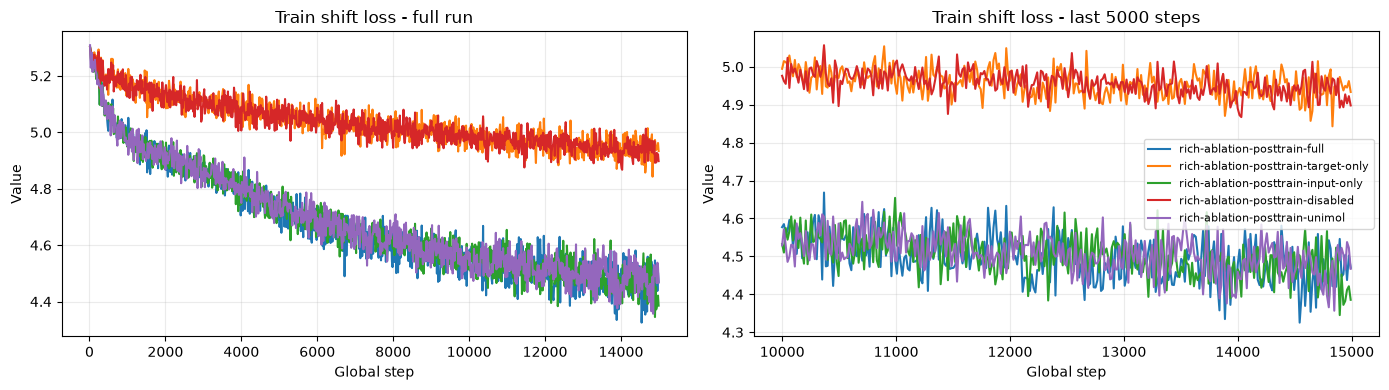

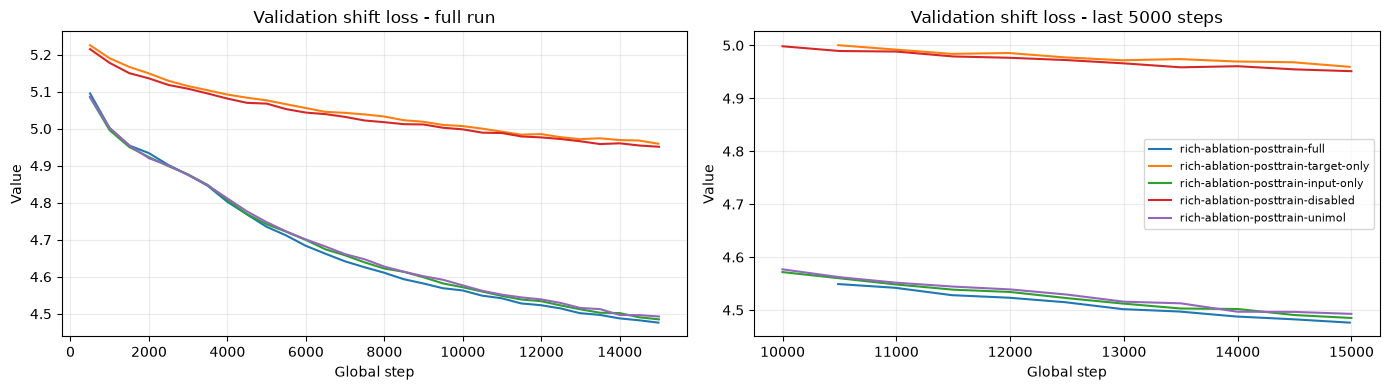

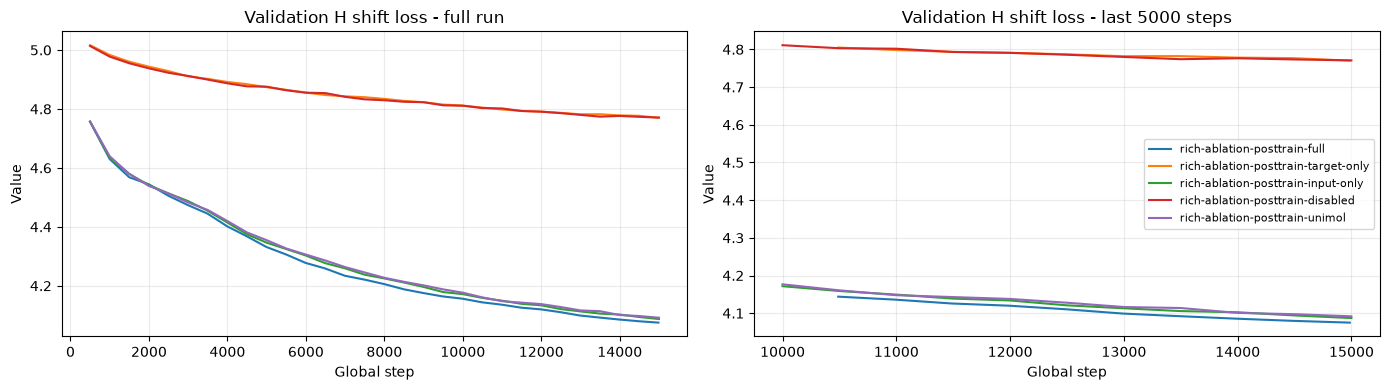

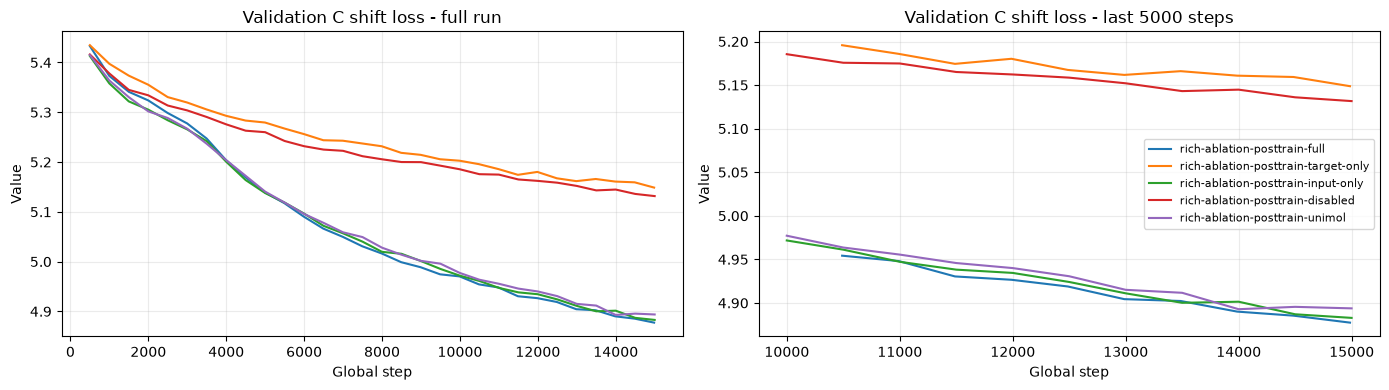

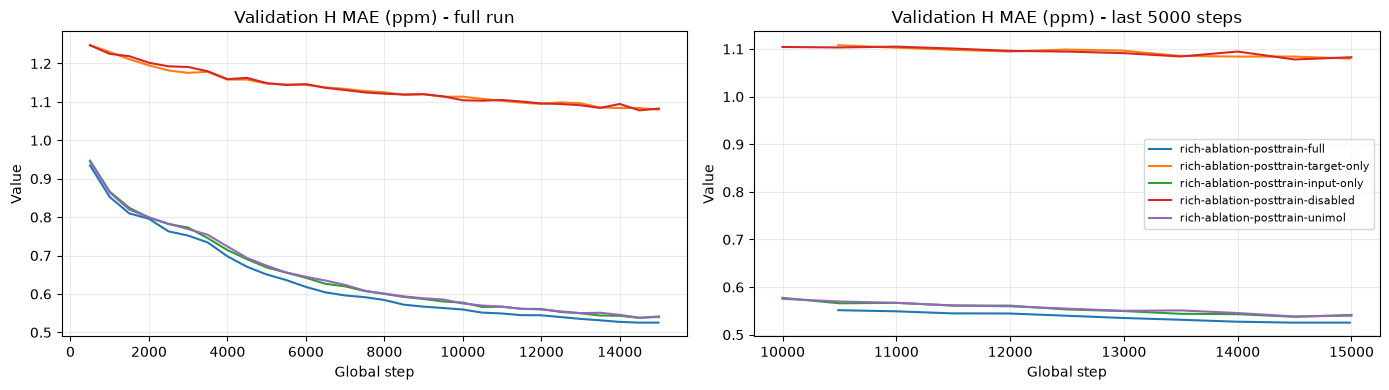

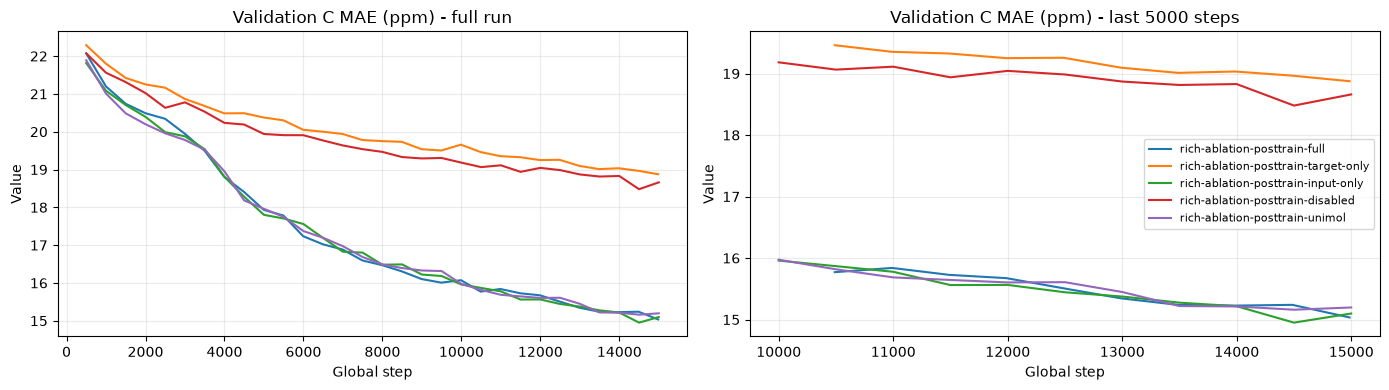

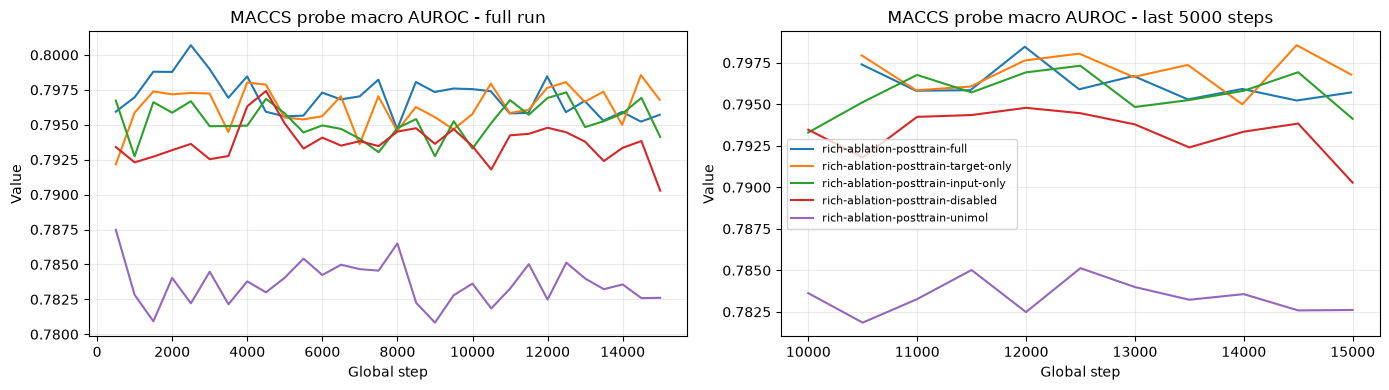

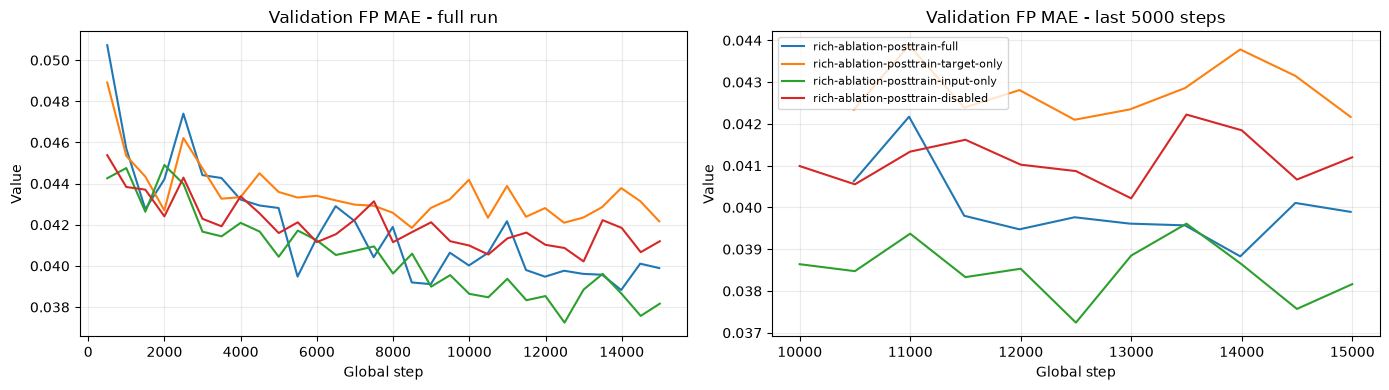

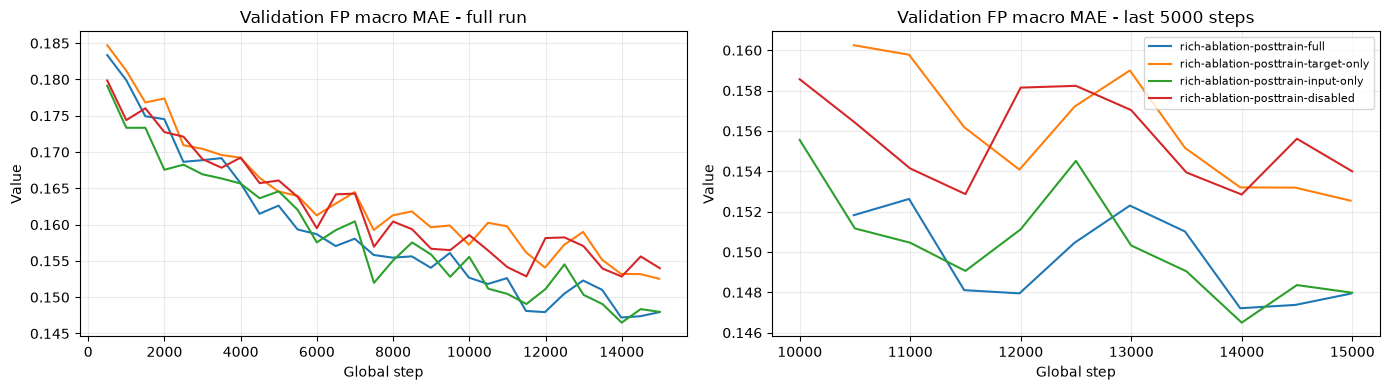

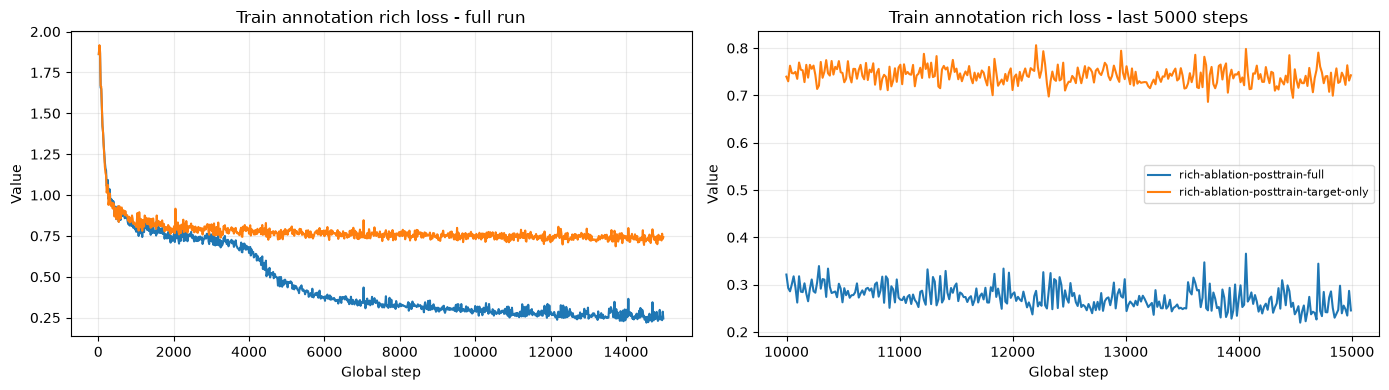

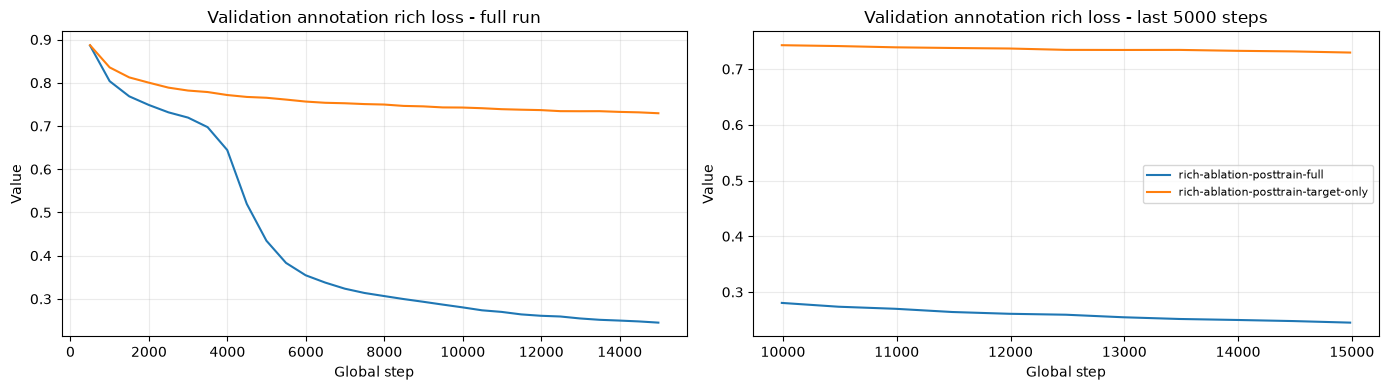

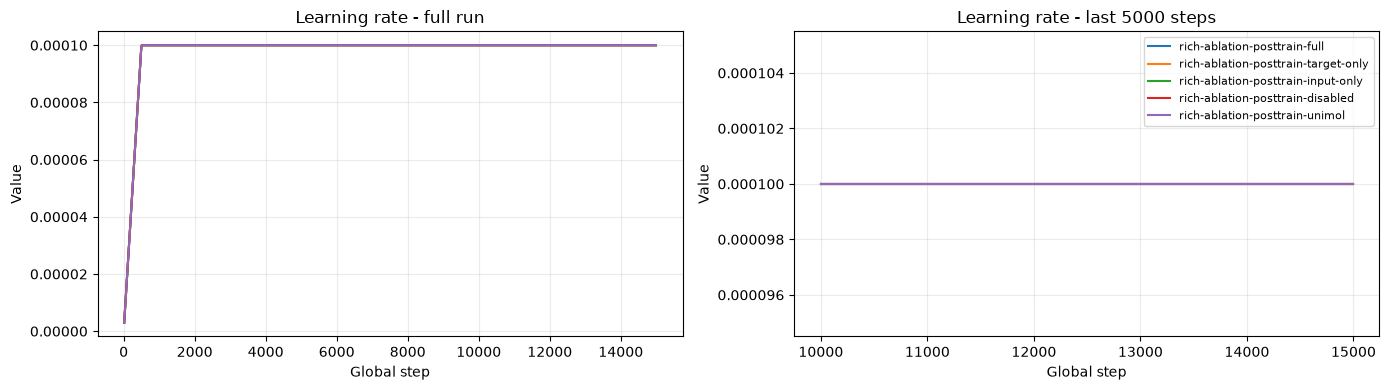

In [4]:
plot_metrics = {
    "train/shift": "Train shift loss",
    "val/shift": "Validation shift loss",
    "val/shift_h": "Validation H shift loss",
    "val/shift_c": "Validation C shift loss",
    "val/shift/h_mae_ppm": "Validation H MAE (ppm)",
    "val/shift/c_mae_ppm": "Validation C MAE (ppm)",
    "probe/maccs_macro_auroc": "MACCS probe macro AUROC",
    "val/fp_mae": "Validation FP MAE",
    "val/fp_macro_mae": "Validation FP macro MAE",
    "train/rich": "Train annotation rich loss",
    "val/annotation": "Validation annotation rich loss",
    "lr-AdamW": "Learning rate",
}

run_names = history["run_name"].drop_duplicates().tolist()
colors = plt.get_cmap("tab10").colors
run_colors = {name: colors[index % len(colors)] for index, name in enumerate(run_names)}

def plot_metric(metric, title, n_steps=5000):
    data = history[history["metric"] == metric].copy()
    if data.empty:
        print(f"{metric}: not logged in this experiment")
        return

    last_step = data["step"].max()
    closeup = data[data["step"] >= last_step - n_steps].copy()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

    for run_name, group in data.groupby("run_name", sort=False):
        group = group.sort_values("step")
        axes[0].plot(group["step"], group["value"], label=run_name, color=run_colors[run_name])
    for run_name, group in closeup.groupby("run_name", sort=False):
        group = group.sort_values("step")
        axes[1].plot(group["step"], group["value"], label=run_name, color=run_colors[run_name])

    axes[0].set_title(f"{title} - full run")
    axes[1].set_title(f"{title} - last {n_steps} steps")
    for axis in axes:
        axis.set(xlabel="Global step", ylabel="Value")
        axis.grid(alpha=0.25)
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

for metric, title in plot_metrics.items():
    plot_metric(metric, title)

## Resources and initial interpretation

GPU memory was logged once at the end of each run. `duration_minutes` is derived from MLflow timestamps; no explicit execution-time or throughput metric was logged. The final comparison should be read together with the curve shapes because these runs did not reach convergence.

In [5]:
resource_columns = [
    'run_name', 'status', 'script_scope', 'duration_minutes',
    'gpu_peak_allocated_mb', 'gpu_peak_reserved_mb',
]
resources = last[resource_columns].copy()
resources.iloc[:, 3:] = resources.iloc[:, 3:].apply(pd.to_numeric, errors='coerce').round(2)
resources

,run_name,status,script_scope,duration_minutes,gpu_peak_allocated_mb,gpu_peak_reserved_mb
0,rich-ablation-posttrain-full,FAILED,script_run,281.44,67679.99,89390.0
1,rich-ablation-posttrain-target-only,FINISHED,script_run,271.78,67678.76,89390.0
2,rich-ablation-posttrain-input-only,FINISHED,script_run,323.33,67684.54,81202.0
3,rich-ablation-posttrain-disabled,FINISHED,script_run,323.20,67684.54,81202.0
4,rich-ablation-posttrain-unimol,FINISHED,extra_run_in_experiment,326.18,67663.15,73402.0


For quantitative conclusions, focus on the final `val/shift`, H/C MAE, the probe, and, for rich configurations, the two annotation losses. The `full` run is marked FAILED in MLflow but has metrics through its last available step, so its status should remain visible when interpreting the result.